# Problem Set 8

## Objective: Replicate Cooper and Ejarque Table 3 results using a simulated method of moments approach. 

In [155]:
# Import packages

from IPython.display import Image, display

In [156]:
# Relative paths

In [157]:
# Steps for SMM

# Find data moments (likely calculate these yourself using microdata, but may also get from others)
# Make a guess at model parameters
# Set up model solution (e.g. VFI for a dynamic programming problem)
# Simulate model/find stationary distribution
# Calculate model moments
# Find distance between data and model moments (using optimal weight matrix)
# Update guess at parameter vector using a numerical optimization routine
# Continue until minimize distance between data and model moments

#Per CE, the methodology is:
# 1. For a given \theta, solve $(1)$, along \(4\) and \(8\)
# 2. Resulting policy function  are used to create a panel data set
# 3. $\Psi_s(\theta)$ is obtained from the panel.
# Goal: SMM is solved by simulation
    #psi^d = [0.03, 0.24, 0.4, 0.25, 3.0]

# Table 3 compares internal and external finance and takes the max of the two.


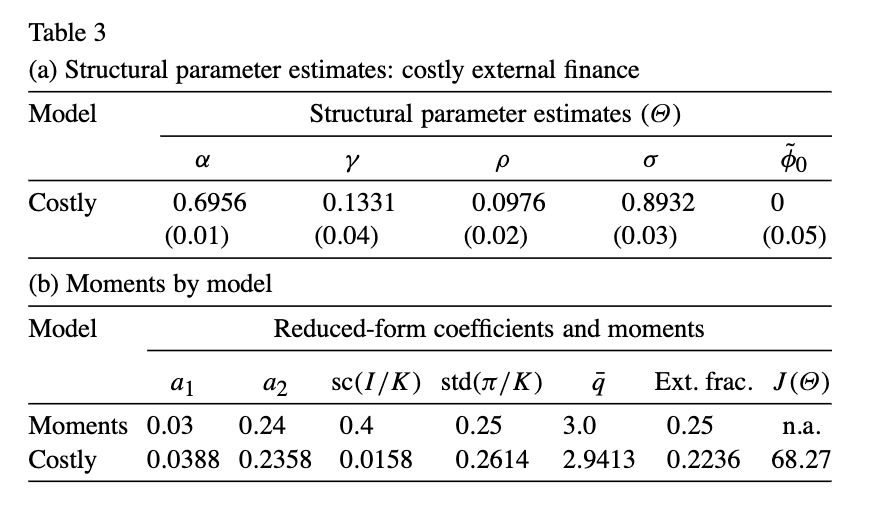

In [158]:

display(Image(filename="ProblemSet8/Table3_CooperEjarque.png"))

Steps to solve:

objective(theta):
    build shock process using rho, sigma
    solve Bellman equation
    get policy function
    simulate panel
    calculate simulated moments
    compare simulated moments to data moments
    return weighted distance



In [1]:
# Files and Corresponding functions

#1. Bash - bash_PS8.sh
#2. Compiler for python code and latex - compile_PS8.py
        #2a. Dependency: PS8latex.tex
        #2b. Dependency: PS8style.sty
    #3. Configuration (applies to all scripts further down) - config.py
    #4. Model - model.py
    #5. Simulation - simulate.py
    #6. Moments - moments.py
    #7. SMM - smm.py

#All  work will completed here to ensure functionality and then seperated into different .py files.

In [160]:
#main.py

In [2]:
# config.py

#--------Packages
from pathlib import Path

### Below from SMM notes
import pandas as pd
import matplotlib.pyplot as plt
import dask
from dask import delayed, compute
from dask.distributed import Client
import scipy.optimize as optimize
import scipy.stats as stats
import plotly.express as px

!{sys.executable} -m pip install quantecon
import quantecon as qe
from quantecon.markov.approximation import tauchen

#---------relative path configuration

# Root = folder containing config.py

from pathlib import Path

try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    ROOT = Path.cwd()

SCRIPTS = ROOT / "scripts"
RESULTS = ROOT / "results"

RESULTS.mkdir(exist_ok=True)

print("Setup successful")
print(f"ROOT: {ROOT}")
print(f"SCRIPTS: {SCRIPTS}")
print(f"RESULTS: {RESULTS}")

#--------CE Fixed Parameters

beta = 0.95      # discount factor
delta = 0.15     # depreciation rate
p = 1.0          # price of capital

#--------SMM starting parameters

alpha = 0.70
gamma = 0.13
rho = 0.10
sigma = 0.89
phi0 = 0.0

theta0 = [
    alpha,
    gamma,
    rho,
    sigma,
    phi0
]


# -------------------------
# Target moments: Table 3
# -------------------------

target_moments = [
    0.03,   # a1
    0.24,   # a2
    0.40,   # serial correlation of I/K
    0.25,   # std(pi/K)
    3.00,   # average Q
    0.25    # fraction externally financed
]

#psi^d = [0.03,0.24, 0.4, 0.25, 3.0]

zsh:1: parse error near `-m'
Setup successful
ROOT: /Users/marlifirillo/CompEcon_Fall25/DynamicProgramming
SCRIPTS: /Users/marlifirillo/CompEcon_Fall25/DynamicProgramming/scripts
RESULTS: /Users/marlifirillo/CompEcon_Fall25/DynamicProgramming/results


In [4]:
# model.py

import numpy as np


"""
# V(K,A) = max(K') [ profit - investment - adjustment_cost
#                    + beta * E[V(K',A') | A] ]

#model.py process:
    #Tauchen (AR(1))
    #Solve DP problem
    #Simulate data
    #Calculate 6 moments (Table 3)
    #Compare with targets

"""

###### GRIDS (A, K)
# A process: Tauchen approximation to AR(1)

def make_A_process(rho, sigma, nA=5):

    mc = tauchen(
        n=nA,
        rho=rho,
        sigma=sigma
    )

    logA_grid = np.asarray(mc.state_values)
    P = np.asarray(mc.P)

    # Ensure transition probabilities are valid
    P = np.where(P < 0, 0.0, P)
    P = P / P.sum(axis=1, keepdims=True)

    A_grid = np.exp(logA_grid)

    return A_grid, P

# K (Capital) grid
def make_K_grid(K_min=1.0, K_max=1000.0, nK=300):
    return np.linspace(K_min, K_max, nK)

################################################

##### DP COMPONENTS

# Profit function
def profit(K, A, alpha):
    return A * K**alpha

# Investment
def investment(K, K_next, delta):
    return K_next - (1 - delta) * K

# Adjustment cost
def adjustment_cost(K, K_next, gamma, delta):
    I = investment(K, K_next, delta)
    return (gamma / 2) * (I / K)**2 * K

#### TABLE 3 SPECIFICATION (INTERNAL VS. EXTERNAL)
"""Eq. 10 and 11"""


# Internal finance payoff
def internal_payoff(K, K_next, A, alpha, gamma, delta):
    pi = profit(K, A, alpha)
    I = investment(K, K_next, delta)
    # Internal finance constraint
    if I > pi:
        return -np.inf
    adj_cost = adjustment_cost(
        K,
        K_next,
        gamma,
        delta
    )
    return pi - I - adj_cost

# External finance payoff
def external_payoff(
    K,
    K_next,
    A,
    alpha,
    gamma,
    delta,
    phi0,
    phi1=0.0
):
    pi = profit(K, A, alpha)
    I = investment(K, K_next, delta)
    external_finance = I - pi
    # External finance only used when investment exceeds profits
    if external_finance <= 0:
        return -np.inf
    adj_cost = adjustment_cost(
        K,
        K_next,
        gamma,
        delta
    )
    finance_cost = phi0 + phi1 * external_finance
    return pi - I - adj_cost - finance_cost


##### DP PUTTING IT ALL TOGETHER
#CooperEjarqueModel

def CooperEjarqueModel(
    K_grid,
    A_grid,
    P,
    alpha,
    gamma,
    delta,
    beta,
    phi0,
    phi1=0.0,
    v_tol=1e-6,
    max_iter=1000
):
    nK = len(K_grid)
    nA = len(A_grid)

    # Initial guess for value function
    V = np.zeros((nK, nA))
    # Stores optimal K_next choice
    policy = np.zeros((nK, nA), dtype=int)
    # Stores financing choice
    # 0 = internal
    # 1 = external
    finance_policy = np.zeros((nK, nA), dtype=int)
    V_dist = 10
    iteration = 0
    while (V_dist > v_tol) and (iteration < max_iter):
        V_new = np.zeros_like(V)
        for iK, K in enumerate(K_grid):
            for iA, A in enumerate(A_grid):
                values = np.full(nK, -np.inf)
                # Stores financing choice for each possible K_next
                financing_choices = np.zeros(nK, dtype=int)
                for iKp, K_next in enumerate(K_grid):
                    # Internal finance payoff
                    payoff_internal = internal_payoff(
                        K,
                        K_next,
                        A,
                        alpha,
                        gamma,
                        delta
                    )
                    # External finance payoff
                    payoff_external = external_payoff(
                        K,
                        K_next,
                        A,
                        alpha,
                        gamma,
                        delta,
                        phi0,
                        phi1
                    )
                    # Choose financing option with highest current payoff
                    if payoff_internal >= payoff_external:
                        payoff = payoff_internal
                        financing_choices[iKp] = 0
                    else:
                        payoff = payoff_external
                        financing_choices[iKp] = 1
                    # Expected value next period
                    expected_value = P[iA, :] @ V[iKp, :]
                    # Bellman RHS
                    values[iKp] = payoff + beta * expected_value
                # Choose K' that maximizes firm value
                best_iKp = np.argmax(values)

# Expected value of the next period
                V_new[iK, iA] = values[best_iKp]
                policy[iK, iA] = best_iKp
                finance_policy[iK, iA] = financing_choices[best_iKp]

        # Check convergence
        V_dist = np.max(np.abs(V_new - V))

        V = V_new
        iteration += 1

    return V, policy, finance_policy

A_grid, P = make_A_process(
    rho,
    sigma
)

K_grid = make_K_grid()


# Solve DP problem

V, policy, finance_policy = CooperEjarqueModel(
    K_grid,
    A_grid,
    P,
    alpha,
    gamma,
    delta,
    beta,
    phi0,
    phi1=0
)

In [15]:
# Simulate one firm from solved policy function

def simulate_firm(
    policy,
    finance_policy,
    V,
    K_grid,
    A_grid,
    P,
    alpha,
    delta,
    T,
    seed
):

    rng = np.random.default_rng(seed)

    nK = len(K_grid)
    nA = len(A_grid)

    K = np.zeros(T)
    I = np.zeros(T)
    Q = np.zeros(T)
    EQ_ = np.zeros(T)
    CF = np.zeros(T)
    external_finance = np.zeros(T)

    # Starting states
    iK = nK // 2
    iA = nA // 2

    for t in range(T):

        K_current = K_grid[iK]
        A_current = A_grid[iA]

        K[t] = K_current

        # Optimal K_next from solved DP
        iK_next = policy[iK, iA]
        K_next = K_grid[iK_next]

        # Investment
        I[t] = investment(
            K_current,
            K_next,
            delta
        )

        # Cash flow
        CF[t] = profit(
            K_current,
            A_current,
            alpha
        )

        # Average Q
        Q[t] = V[iK, iA] / K_current

        #Expected next-period average Q
        # External finance
        if finance_policy[iK, iA] == 1:
            external_finance[t] = max(
                I[t] - CF[t],
                0.0
            )

        # Move to next period
        if t < T - 1:

            iK = iK_next

            iA = rng.choice(
                nA,
                p=P[iA, :]
            )

    return K, I, Q, CF, external_finance


# Simulate panel of firms using Dask

def simulate_panel(
    policy,
    finance_policy,
    V,
    K_grid,
    A_grid,
    P,
    alpha,
    delta,
    S=1000,
    T=50,
    seed=1234
):

    tasks = []

    for s in range(S):

        task = delayed(simulate_firm)(
            policy,
            finance_policy,
            V,
            K_grid,
            A_grid,
            P,
            alpha,
            delta,
            T,
            seed + s
        )

        tasks.append(task)

    results = compute(*tasks)

    K = np.array([r[0] for r in results])
    I = np.array([r[1] for r in results])
    Q = np.array([r[2] for r in results])
    EQ_next = np.array([r[3] for r in results])
    CF = np.array([r[4] for r in results])
    external_finance = np.array([r[5] for r in results])

    return K, I, Q, EQ_next, CF, external_finance


    K, I, Q, EQ_next, CF, external_finance = simulate_panel(
        policy,
        finance_policy,
        V,
        K_grid,
        A_grid,
        P,
        alpha,
        delta
    )

In [9]:
print("K shape:", K.shape)
print("I shape:", I.shape)
print("Q shape:", Q.shape)
print("CF shape:", CF.shape)

print("\nMean K:", np.mean(K))
print("Mean I:", np.mean(I))
print("Mean I/K:", np.mean(I / K))
print("Mean Q:", np.mean(Q))
print("Mean CF/K:", np.mean(CF / K))

K shape: (1000, 50)
I shape: (1000, 50)
Q shape: (1000, 50)
CF shape: (1000, 50)

Mean K: 298.7855284280937
Mean I: 40.57999775919733
Mean I/K: 0.14368813166040562
Mean Q: 2.8137129280844513
Mean CF/K: 0.2871293894886885


In [17]:
# Step 3: Compute moments from simulated data
# Step 3: Compute moments from simulated data

def compute_moments(
    K,
    I,
    Q,
    EQ_next,
    CF,
    external_finance
):

    # Investment rate
    I_K = I / K

    # Profit / cash flow rate
    CF_K = CF / K

    # Q regression
    # I/K = a0 + a1*E[Q_next] + a2*CF/K + error

    y = I_K.ravel()

    X = np.column_stack([
        np.ones(len(y)),
        EQ_next.ravel(),
        CF_K.ravel()
    ])

    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    a1 = coefficients[1]
    a2 = coefficients[2]

    # Serial correlation of I/K
    serial_corr = np.corrcoef(
        I_K[:, :-1].ravel(),
        I_K[:, 1:].ravel()
    )[0, 1]

    # Standard deviation of profit / cash flow rate
    std_CF_K = np.std(CF_K)

    # Mean average Q
    mean_Q = np.mean(Q)

    # Fraction of total investment financed externally
    total_investment = np.maximum(
        I,
        0.0
    ).sum()

    external_fraction = (
        external_finance.sum()
        / total_investment
    )

    # Simulated moments
    psi_s = np.array([
        a1,
        a2,
        serial_corr,
        std_CF_K,
        mean_Q,
        external_fraction
    ])

    return psi_s

psi_d = np.array([
    0.03,   # a1
    0.24,   # a2
    0.40,   # sc(I/K)
    0.25,   # std(pi/K)
    3.00,   # mean average Q
    0.25    # external finance fraction
])


In [18]:
diff = psi_s - psi_d

print("Simulated moments:")
print(psi_s)

print("\nTarget moments:")
print(psi_d)

print("\nDifference:")
print(diff)

Simulated moments:
[ 0.28589498 -0.11520652 -0.0545495   0.3442107   2.81371293  0.03784589]

Target moments:
[0.03 0.24 0.4  0.25 3.   0.25]

Difference:
[ 0.25589498 -0.35520652 -0.4545495   0.0942107  -0.18628707 -0.21215411]


In [ ]:
# model.py

import numpy as np
from quantecon.markov.approximation import tauchen
from dask import delayed, compute


"""
Cooper and Ejarque (2003) - Table 3 replication

Process:
    1. Create productivity process using Tauchen
    2. Create capital grid
    3. Solve DP problem
    4. Simulate panel of firms
    5. Calculate 6 Table 3 moments
    6. Compare simulated moments with data targets
"""


################################################
##### PARAMETERS FOR TESTING / REPLICATION

# Table 3 reported estimates
alpha = 0.6956
gamma = 0.1331
rho = 0.0976
sigma = 0.8932
phi0 = 0.0

# Calibrated parameters
delta = 0.15
beta = 0.95
phi1 = 0.0


################################################
##### GRIDS (A, K)


# A process: Tauchen approximation to AR(1)

def make_A_process(rho, sigma, nA=5):

    mc = tauchen(
        n=nA,
        rho=rho,
        sigma=sigma
    )

    logA_grid = np.asarray(mc.state_values)
    P = np.asarray(mc.P)

    # Ensure transition probabilities are valid
    P = np.where(P < 0, 0.0, P)
    P = P / P.sum(axis=1, keepdims=True)

    A_grid = np.exp(logA_grid)

    return A_grid, P


# K (Capital) grid

def make_K_grid(
    K_min=1.0,
    K_max=1000.0,
    nK=300
):

    return np.linspace(
        K_min,
        K_max,
        nK
    )


################################################
##### DP COMPONENTS


# Profit function

def profit(K, A, alpha):

    return A * K**alpha


# Investment

def investment(K, K_next, delta):

    return K_next - (1 - delta) * K


# Adjustment cost

def adjustment_cost(
    K,
    K_next,
    gamma,
    delta
):

    I = investment(
        K,
        K_next,
        delta
    )

    return (
        (gamma / 2)
        * (I / K)**2
        * K
    )


################################################
##### TABLE 3 SPECIFICATION
##### Eq. 10-12: Internal vs. external finance


# Internal finance current payoff

def internal_payoff(
    K,
    K_next,
    A,
    alpha,
    gamma,
    delta
):

    pi = profit(
        K,
        A,
        alpha
    )

    I = investment(
        K,
        K_next,
        delta
    )

    # Internal finance constraint:
    # I <= pi

    if I > pi:

        return -np.inf

    adj_cost = adjustment_cost(
        K,
        K_next,
        gamma,
        delta
    )

    return (
        pi
        - I
        - adj_cost
    )


# External finance current payoff

def external_payoff(
    K,
    K_next,
    A,
    alpha,
    gamma,
    delta,
    phi0,
    phi1=0.0
):

    pi = profit(
        K,
        A,
        alpha
    )

    I = investment(
        K,
        K_next,
        delta
    )

    external_finance = I - pi

    # External finance only used if:
    # I > pi

    if external_finance <= 0:

        return -np.inf

    adj_cost = adjustment_cost(
        K,
        K_next,
        gamma,
        delta
    )

    finance_cost = (
        phi0
        + phi1 * external_finance
    )

    return (
        pi
        - I
        - adj_cost
        - finance_cost
    )


################################################
##### DP SOLVER


def CooperEjarqueModel(
    K_grid,
    A_grid,
    P,
    alpha,
    gamma,
    delta,
    beta,
    phi0,
    phi1=0.0,
    v_tol=1e-6,
    max_iter=1000
):

    nK = len(K_grid)
    nA = len(A_grid)

    # Initial guess for value function
    V = np.zeros(
        (nK, nA)
    )

    # Stores optimal K_next index
    policy = np.zeros(
        (nK, nA),
        dtype=int
    )

    # Financing choice:
    # 0 = internal
    # 1 = external
    finance_policy = np.zeros(
        (nK, nA),
        dtype=int
    )

    V_dist = 10.0
    iteration = 0

    while (
        V_dist > v_tol
        and iteration < max_iter
    ):

        V_new = np.zeros_like(V)

        for iK, K in enumerate(K_grid):

            for iA, A in enumerate(A_grid):

                values = np.full(
                    nK,
                    -np.inf
                )

                financing_choices = np.zeros(
                    nK,
                    dtype=int
                )

                for iKp, K_next in enumerate(K_grid):

                    # Internal finance payoff
                    payoff_internal = internal_payoff(
                        K,
                        K_next,
                        A,
                        alpha,
                        gamma,
                        delta
                    )

                    # External finance payoff
                    payoff_external = external_payoff(
                        K,
                        K_next,
                        A,
                        alpha,
                        gamma,
                        delta,
                        phi0,
                        phi1
                    )

                    # Choose feasible financing regime
                    if payoff_internal >= payoff_external:

                        payoff = payoff_internal
                        financing_choices[iKp] = 0

                    else:

                        payoff = payoff_external
                        financing_choices[iKp] = 1

                    # Expected value next period
                    expected_value = (
                        P[iA, :]
                        @ V[iKp, :]
                    )

                    # Bellman RHS
                    values[iKp] = (
                        payoff
                        + beta * expected_value
                    )

                # Optimal K_next
                best_iKp = np.argmax(
                    values
                )

                V_new[iK, iA] = (
                    values[best_iKp]
                )

                policy[iK, iA] = (
                    best_iKp
                )

                finance_policy[iK, iA] = (
                    financing_choices[best_iKp]
                )

        # Check convergence
        V_dist = np.max(
            np.abs(V_new - V)
        )

        V = V_new

        iteration += 1

    print(
        "DP iterations:",
        iteration
    )

    print(
        "Final V distance:",
        V_dist
    )

    return (
        V,
        policy,
        finance_policy
    )


################################################
##### CREATE GRIDS


A_grid, P = make_A_process(
    rho,
    sigma
)

K_grid = make_K_grid()


################################################
##### SOLVE DP


V, policy, finance_policy = CooperEjarqueModel(
    K_grid,
    A_grid,
    P,
    alpha,
    gamma,
    delta,
    beta,
    phi0,
    phi1
)


################################################
##### DP DIAGNOSTICS


print("\nA grid:")
print(A_grid)

print("\nP row sums:")
print(
    P.sum(axis=1)
)

print(
    "\nK policy min index:",
    policy.min()
)

print(
    "K policy max index:",
    policy.max()
)

print(
    "Share at lower K bound:",
    np.mean(policy == 0)
)

print(
    "Share at upper K bound:",
    np.mean(
        policy == len(K_grid) - 1
    )
)

print(
    "External finance state share:",
    np.mean(finance_policy == 1)
)


################################################
##### SIMULATE ONE FIRM


def simulate_firm(
    policy,
    finance_policy,
    V,
    K_grid,
    A_grid,
    P,
    alpha,
    delta,
    T,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    nK = len(K_grid)
    nA = len(A_grid)

    K = np.zeros(T)
    I = np.zeros(T)
    Q = np.zeros(T)
    EQ_next = np.zeros(T)
    CF = np.zeros(T)
    external_finance = np.zeros(T)

    # Starting states
    iK = nK // 2
    iA = nA // 2

    for t in range(T):

        K_current = K_grid[iK]
        A_current = A_grid[iA]

        K[t] = K_current

        # Optimal K_next
        iK_next = policy[
            iK,
            iA
        ]

        K_next = K_grid[
            iK_next
        ]

        # Investment
        I[t] = investment(
            K_current,
            K_next,
            delta
        )

        # Profit / cash flow
        CF[t] = profit(
            K_current,
            A_current,
            alpha
        )

        # Average Q
        Q[t] = (
            V[iK, iA]
            / K_current
        )

        # Expected average Q next period
        Q_next_states = (
            V[iK_next, :]
            / K_next
        )

        EQ_next[t] = (
            P[iA, :]
            @ Q_next_states
        )

        # External finance
        if finance_policy[iK, iA] == 1:

            external_finance[t] = max(
                I[t] - CF[t],
                0.0
            )

        # Move to next period
        if t < T - 1:

            iK = iK_next

            iA = rng.choice(
                nA,
                p=P[iA, :]
            )

    return (
        K,
        I,
        Q,
        EQ_next,
        CF,
        external_finance
    )


################################################
##### SIMULATE PANEL USING DASK


def simulate_panel(
    policy,
    finance_policy,
    V,
    K_grid,
    A_grid,
    P,
    alpha,
    delta,
    S=1000,
    T=50,
    seed=1234
):

    tasks = []

    for s in range(S):

        task = delayed(
            simulate_firm
        )(
            policy,
            finance_policy,
            V,
            K_grid,
            A_grid,
            P,
            alpha,
            delta,
            T,
            seed + s
        )

        tasks.append(task)

    results = compute(
        *tasks
    )

    K = np.array([
        r[0]
        for r in results
    ])

    I = np.array([
        r[1]
        for r in results
    ])

    Q = np.array([
        r[2]
        for r in results
    ])

    EQ_next = np.array([
        r[3]
        for r in results
    ])

    CF = np.array([
        r[4]
        for r in results
    ])

    external_finance = np.array([
        r[5]
        for r in results
    ])

    return (
        K,
        I,
        Q,
        EQ_next,
        CF,
        external_finance
    )


################################################
##### RUN SIMULATION


K, I, Q, EQ_next, CF, external_finance = simulate_panel(
    policy,
    finance_policy,
    V,
    K_grid,
    A_grid,
    P,
    alpha,
    delta
)


################################################
##### SIMULATION DIAGNOSTICS


print(
    "\nK shape:",
    K.shape
)

print(
    "I shape:",
    I.shape
)

print(
    "Q shape:",
    Q.shape
)

print(
    "EQ_next shape:",
    EQ_next.shape
)

print(
    "CF shape:",
    CF.shape
)

print(
    "External finance shape:",
    external_finance.shape
)

print(
    "\nMean K:",
    np.mean(K)
)

print(
    "Mean I:",
    np.mean(I)
)

print(
    "Mean I/K:",
    np.mean(I / K)
)

print(
    "Mean Q:",
    np.mean(Q)
)

print(
    "Mean CF/K:",
    np.mean(CF / K)
)


# Step 3: Compute Table 3 moments from simulated data

def compute_moments(
    K,
    I,
    Q,
    EQ_next,
    CF,
    external_finance
):

    # Investment rate
    I_K = I / K

    # Profit rate
    CF_K = CF / K


    # -----------------------------------
    # Q regression with firm fixed effects
    #
    # I/K = a_i + a1*E[Q_next]
    #             + a2*(pi/K) + error
    #
    # Remove firm-specific means
    # -----------------------------------

    y_fe = (
        I_K
        - I_K.mean(axis=1, keepdims=True)
    )

    EQ_fe = (
        EQ_next
        - EQ_next.mean(axis=1, keepdims=True)
    )

    CF_fe = (
        CF_K
        - CF_K.mean(axis=1, keepdims=True)
    )

    y = y_fe.ravel()

    X = np.column_stack([
        EQ_fe.ravel(),
        CF_fe.ravel()
    ])

    coefficients = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )[0]

    a1 = coefficients[0]
    a2 = coefficients[1]


    # -----------------------------------
    # Serial correlation of I/K
    # -----------------------------------

    serial_corr = np.corrcoef(
        I_K[:, :-1].ravel(),
        I_K[:, 1:].ravel()
    )[0, 1]


    # -----------------------------------
    # Standard deviation of profit rate
    # -----------------------------------

    std_profit_rate = np.std(
        CF_K
    )


    # -----------------------------------
    # Mean average Q
    # -----------------------------------

    mean_Q = np.mean(
        Q
    )


    # -----------------------------------
    # Fraction of investment financed
    # externally
    # -----------------------------------

    total_investment = (
        I[I > 0].sum()
    )

    external_fraction = (
        external_finance.sum()
        / total_investment
    )


    psi_s = np.array([
        a1,
        a2,
        serial_corr,
        std_profit_rate,
        mean_Q,
        external_fraction
    ])

    return psi_s

################################################
##### SIMULATED MOMENTS


psi_s = compute_moments(
    K,
    I,
    Q,
    EQ_next,
    CF,
    external_finance
)


################################################
##### TABLE 3 DATA TARGETS


psi_d = np.array([
    0.03,   # a1
    0.24,   # a2
    0.40,   # sc(I/K)
    0.25,   # std(pi/K)
    3.00,   # mean average Q
    0.25    # external finance fraction
])


################################################
##### PAPER TABLE 3 COSTLY MODEL RESULTS


psi_paper = np.array([
    0.0388,
    0.2358,
    0.0158,
    0.2614,
    2.9413,
    0.2236
])


################################################
##### COMPARE MOMENTS


print(
    "\nYour simulated moments:"
)

print(
    psi_s
)

print(
    "\nEmpirical target moments:"
)

print(
    psi_d
)

print(
    "\nPaper costly-model moments:"
)

print(
    psi_paper
)

print(
    "\npsi_s - psi_d:"
)

print(
    psi_s - psi_d
)

print(
    "\npsi_s - paper costly row:"
)

print(
    psi_s - psi_paper
)


################################################
##### INITIAL SMM OBJECTIVE


W = np.eye(
    len(psi_d)
)

diff = (
    psi_s
    - psi_d
)

J = (
    diff.T
    @ W
    @ diff
)

print(
    "\nSMM objective J:",
    J
)

DP iterations: 333
Final V distance: 9.895852599584032e-07

A grid:
[ 0.06771453  0.26022015  1.          3.84289989 14.76787958]

P row sums:
[1. 1. 1. 1. 1.]

K policy min index: 3
K policy max index: 202
Share at lower K bound: 0.0
Share at upper K bound: 0.0
External finance state share: 0.166

K shape: (1000, 50)
I shape: (1000, 50)
Q shape: (1000, 50)
EQ_next shape: (1000, 50)
CF shape: (1000, 50)
External finance shape: (1000, 50)

Mean K: 273.3735076923077
Mean I: 36.245507157190644
Mean I/K: 0.14186344284543695
Mean Q: 2.845930454855247
Mean CF/K: 0.28882391238582744

Your simulated moments:
[ 0.21458943  0.23356571 -0.01742315  0.34810176  2.84593045  0.03845397]

Empirical target moments:
[0.03 0.24 0.4  0.25 3.   0.25]

Paper costly-model moments:
[0.0388 0.2358 0.0158 0.2614 2.9413 0.2236]

psi_s - psi_d:
[ 0.18458943 -0.00643429 -0.41742315  0.09810176 -0.15406955 -0.21154603]

psi_s - paper costly row:
[ 0.17578943 -0.00223429 -0.03322315  0.08670176 -0.09536955 -0.18514